In [3]:
import torch
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel, AutoConfig

In [4]:
MODEL_ID = 'skt/kogpt2-base-v2'

In [5]:
# ⚠️ AutoTokenizer 로 열면 깨진다. 이 모델은 아래 방식으로 연다.
#    아래 다섯 개는 "문장 시작/끝/모르는 글자/자리 채우기/빈칸" 을 뜻하는 특수 토큰 이름이다.
#    KoGPT2 는 이 이름들을 저장소에 적어 두지 않아서, 우리가 열 때 직접 알려 줘야 한다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL_ID,
    bos_token="</s>", eos_token="</s>",
    unk_token="<unk>", pad_token="<pad>", mask_token="<mask>",
)

# .eval() — 학습이 아니라 사용만 할 것이라는 선언. 오늘은 모델을 고치지 않는다.
model = GPT2LMHeadModel.from_pretrained(MODEL_ID).eval()

# GPU 가 있으면 GPU 로, 없으면 CPU 로. 125M 이라 CPU 로도 돌아간다.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("device :", device)
print("params :", f"{sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 10857.95it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device : cuda
params : 125,164,032


In [7]:
sample = "깊은 산 속에 작은 집이"

print("토큰화 : ", tokenizer.tokenize(sample))
print("복원 : ", tokenizer.decode(tokenizer.encode(sample)))

토큰화 :  ['▁깊은', '▁산', '▁속에', '▁작은', '▁집이']
복원 :  깊은 산 속에 작은 집이


In [10]:
config = AutoConfig.from_pretrained(MODEL_ID)
print(config.vocab_size)            # 모델이 알고있는 토큰(단어)정보의 가짓수 => 51200
print(config.hidden_size)           # 토큰 하나를 벡터화 했을 때 벡터의 길이
print(config.num_hidden_layers)     # 트랜스포머 블록을 몇번 쌓았느냐
print(config.num_attention_heads)   # 멀티헤드어텐션 헤드 수 

51200
768
12
12


In [ ]:
# 모델별 설정비교
FAMILY = {
    "BERT (인코더만)":      "klue/bert-base",
    "GPT2 (디코더만)":      "skt/kogpt2-base-v2",
    "BART (인코더+디코더)": "gogamza/kobart-summarization",
}

FIELDS = ["hidden_size", "num_attention_heads", "num_hidden_layers", "vocab_size"]

print(f"{'':22s} {'type':6s} " + " ".join(f"{f:>20s}" for f in FIELDS))
for label, model_id in FAMILY.items():
    c = AutoConfig.from_pretrained(model_id)
    row = " ".join(f"{getattr(c, f):>20,}" for f in FIELDS)
    print(f"{label:22s} {c.model_type:6s} " + row)
    
# 같은 Body(블록)을 공유하기 때문에 hidden_size는 같지만
# vocab이 다르기 때문에 tokenizer를 섞어 쓰면 안된다.

                       type            hidden_size  num_attention_heads    num_hidden_layers           vocab_size
BERT (인코더만)            bert                    768                   12                   12               32,000
GPT2 (디코더만)            gpt2                    768                   12                   12               51,200
BART (인코더+디코더)         bart                    768                   16                    6               30,000


In [8]:
tokenizer.encode(sample, return_tensors="pt").to(device)

tensor([[11404,  9145, 10671,  9836, 27764]], device='cuda:0')

In [19]:
prompt = sample

In [20]:
last_logits = output.logits [0, -1] # 맨 마지막 번째 토큰은 다음 등장할 토큰의 로짓정보

probs = torch.softmax(last_logits, dim=-1) #다 더하면 1이 되는 확률 정보, 크기 51,200, 순서 안바뀜

torch.topk(probs, 5)        # 상위 5개 - 확률 정보, 단어사전 인덱스 정보
print(prompt, " / 다음에 올 단어 후보")
for score, idx in zip(top.values, top.indices):
    token = tokenizer.decode(idx)
    print(f"{token!r}, {score.item()}")

NameError: name 'output' is not defined

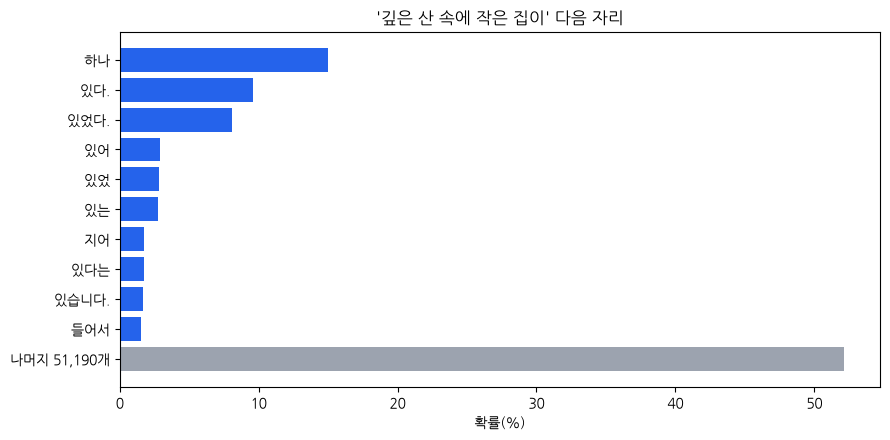

상위 10개 합계 :  47.9%
나머지 51,190개 :  52.1%


In [21]:
# 📋 붙여넣기 [블록 6] — 내 프롬프트의 확률 분포를 막대로
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프의 한글이 □ 로 깨지지 않게 — 설치된 한글 폰트를 찾아 지정한다.
# matplotlib 기본 폰트에는 한글 글자가 없어서 이 부분이 필요하다.
installed = {f.name for f in font_manager.fontManager.ttflist}
for name in ["NanumGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]:
    if name in installed:
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트에서 마이너스 기호가 깨지는 것 방지


def plot_next_token(text, k=10):
    """text 다음에 올 토큰 상위 k개 + 나머지 전부를 막대로 그린다."""
    ids = tokenizer.encode(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(ids).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)

    top = torch.topk(probs, k)
    # 토큰 안의 줄바꿈은 라벨을 깨뜨리므로 지운다
    labels = [tokenizer.decode([i]).replace("\n", "") for i in top.indices.tolist()]
    values = [v * 100 for v in top.values.tolist()]

    rest = 100 - sum(values)                       # 상위 k개를 뺀 나머지 전부
    labels.append(f"나머지 {len(probs) - k:,}개")
    values.append(rest)

    plt.figure(figsize=(9, 4.5))
    plt.barh(range(len(values)), values,
             color=["#2563eb"] * k + ["#9ca3af"])  # 마지막 막대(꼬리)만 회색
    plt.yticks(range(len(values)), labels)
    plt.gca().invert_yaxis()                       # 1등이 맨 위로
    plt.xlabel("확률(%)")
    plt.title(f"'{text}' 다음 자리")
    plt.tight_layout()
    plt.savefig("next_token.png", dpi=120)         # 파일로도 남는다 — 캡처 대신 이걸 내도 된다
    plt.show()

    print(f"상위 {k}개 합계 : {sum(values) - rest:5.1f}%")
    print(f"나머지 {len(probs) - k:,}개 : {rest:5.1f}%")


plot_next_token(prompt)

In [26]:
#1. 토큰화 -> 임베딩
ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
print(tokenizer.decode(ids[0]))
#각 스텝마다 반복해서
for step in range(3):
    with torch.no_grad():
        #2. 모델을 통과해서 마지막 로짓을 꺼낸다.
        logits = model (ids).logits [0, -1]
        #3. 가장 확률이 높은 1등을 선택한다.
        next_id = logits.argmax()
        # 선택된 id를 계속 연결한다. => 연결해서 ids를 늘리고 다시 되돌아간다.
        ids = torch.cat([ids, next_id.view (1, 1)], dim=1)
        print(f"과정 :{tokenizer.decode(next_id)!r}")
print(f"생성 결과: {tokenizer.decode(ids[0])}")

깊은 산 속에 작은 집이
과정 :'하나'
과정 :'있다.\n'
과정 :'그'
생성 결과: 깊은 산 속에 작은 집이 하나 있다.
그


In [30]:
# 생성 함수
with torch.no_grad():
    #토큰 인덱스 정보 텐서 생성 반환
    generated = model.generate(
        tokenizer.encode (prompt, return_tensors="pt").to (device), # 입력 임베딩
        max_new_tokens=3,   # 최대 3번 반복. 위 반복문 step 수와 동일
        do_sample=False,    # 샘플링을 하지 않음 => Greedy 알고리즘 최고 확률만 고른다.
        pad_token_id=tokenizer.pad_token_id #빈 자리 패딩 자리 채우기
    )
    print(tokenizer.decode(generated[0]))   # generate 함수로 3토큰 생성한 결과
    print(tokenizer.decode(ids[0]))         #수제 생성 결과와 동일

깊은 산 속에 작은 집이 하나 있다.
그
깊은 산 속에 작은 집이 하나 있다.
그


In [31]:
#반복 붕괴 현상 :
with torch.no_grad():
    generated = model.generate (
        tokenizer.encode (prompt, return_tensors="pt").to(device),
        max_new_tokens=60,
        #최대 3번 반복. 위 반복문 step 수와 동일
        do_sample=False,
        # 샘플링을 하지 않음 => Greedy 알고리즘 최고 확률만 고른다.
        pad_token_id=tokenizer.pad_token_id #빈 자리 패딩 자리 채우기
    )
    
print(tokenizer.decode (generated[0]))

깊은 산 속에 작은 집이 하나 있다.
그 집은 바로 이 산 속에 있는 작은 집이다.
그 집은 바로 이 산 속에 있는 작은 집이다.
그 집은 바로 이 산 속에 있는 작은 집이다.
그 집은 바로 이 산 속에 있는 작은 집이다.
그 집은 바로 이 산 속에 있는 작은 집이다.
그 집은 바로 이 산 속에 있는 작은


In [32]:
# 반복 붕괴 현상 해결책 -> 반복에 패널티를 준다.
def generate(label, max_new_tokens=60, **options):
    """옵션을 바꿔 가며 생성하고 결과를 출력한다.

    **options — 여기로 do_sample, temperature, top_k ... 가 그대로 넘어간다.
                오늘 배울 디코딩 옵션을 바꿔 끼우는 자리다.
    """
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            ids, max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id, **options,
        )
    # skip_special_tokens=True — </s> 같은 표시를 빼고 사람이 읽을 부분만
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    print(f"=== {label}")
    print(text[len(prompt):].strip(), "\n")   # 프롬프트는 빼고 '이어 쓴 부분'만 보여 준다
    return text

In [33]:
#반복 붕괴현상 해결책 -> 반복에 패널티를 준다.
generate(label="그리디, 반복패널티", do_sample=False, repetition_penalty=1.2)


=== 그리디, 반복패널티
하나 있다.
그 집은 바로 이 집이다.
이 집의 주인은 다름 아닌 '안녕하세요'다.
그는 "아무래도 저는 그 집을 사랑합니다. 제가 사랑하는 사람이기 때문입니다. 제게 있어 주신 은혜에 감사드립니다"라고 말했다.
그러면서 그는 "제가 사는 곳은 우리집 



'깊은 산 속에 작은 집이 하나 있다.\n그 집은 바로 이 집이다.\n이 집의 주인은 다름 아닌 \'안녕하세요\'다.\n그는 "아무래도 저는 그 집을 사랑합니다. 제가 사랑하는 사람이기 때문입니다. 제게 있어 주신 은혜에 감사드립니다"라고 말했다.\n그러면서 그는 "제가 사는 곳은 우리집'

In [34]:
# 빔 서치 : 1등만 가져가는 대신, beam 숫자만큼 후보를 동시에 n개 끌고감. 요즘엔 잘 안씀.
generate("빔 서치", do_sample=False, num_beams=4)

=== 빔 서치
하나 있다.
그 집에는 두 개의 방이 있다.
하나는 작은 방이고 다른 하나는 작은 방이다.
작은 방은 작은 방이고 작은 방은 작은 방이다.
작은 방은 작은 방이고 작은 방은 작은 방이다.
작은 방은 작은 방이고 작은 방은 작은 방이다.
작은 방은 작은 방 



'깊은 산 속에 작은 집이 하나 있다.\n그 집에는 두 개의 방이 있다.\n하나는 작은 방이고 다른 하나는 작은 방이다.\n작은 방은 작은 방이고 작은 방은 작은 방이다.\n작은 방은 작은 방이고 작은 방은 작은 방이다.\n작은 방은 작은 방이고 작은 방은 작은 방이다.\n작은 방은 작은 방'

In [35]:
#샘플링 -> 랜덤하게 확률로 뽑기
torch.manual_seed (0) #랜덤 시드값을 고정
generate("샘플링", do_sample=True)

=== 샘플링
하나 있다.
바로 이 작은 집은 '숲 속의 할머니 집'이다.
산촌마을이라 부르는 산 중턱에 위치한 산채. 집 안에는 할머니가 계셨다.
할머니는 어릴 때부터 이곳에서 살았다.
할머니는 할머니네 집에서 농사일을 하고 있었다.
할머니가 살던 산채는 다른 밭으로 간 것이 아니고 마을 사람들끼리 논 



"깊은 산 속에 작은 집이 하나 있다.\n바로 이 작은 집은 '숲 속의 할머니 집'이다.\n산촌마을이라 부르는 산 중턱에 위치한 산채. 집 안에는 할머니가 계셨다.\n할머니는 어릴 때부터 이곳에서 살았다.\n할머니는 할머니네 집에서 농사일을 하고 있었다.\n할머니가 살던 산채는 다른 밭으로 간 것이 아니고 마을 사람들끼리 논"

In [36]:
# 온도
torch.manual_seed(0)
generate("온도 0.3", do_sample=True, temperature=0.3)
generate("온도 0.5", do_sample=True, temperature=0.5)
generate("온도 1", do_sample=True, temperature=1)
generate("온도 1.5", do_sample=True, temperature=1.5)

=== 온도 0.3
하나 있다.
바로 이 집은 바로 이 집의 주인인 김순자 할머니의 집이다.
김순자 할머니는 이 집의 주인이다.
김순자 할머니는 할머니의 집 부엌에 있는 작은 방에서 할머니의 이야기를 듣고 있다.
할머니가 할머니의 이야기를 듣고 있는 동안 할머니는 할머니의 방에서 나와 

=== 온도 0.5
하나 있다.
그곳에는 세 개의 방이 있다.
그 방에는 두 개의 방이 있는데, 하나는 소파와 세 개의 방이 있다.
그 방에는 두 개의 방이 있는데, 하나는 소파와 세 개의 방이 있다.
그 방에는 세 개의 방이 있다.
그 방에는 두 개의 방이 있다.
그 방에는 두 개의 방이 있는데, 하나는 소 

=== 온도 1
있다”면서 “마을 어르신들이 어르신 가방 챙겨 드시고 또 할머니 할아버지들께서 잘 살아 주셔서 어르신들에게 맛있는 식사를 할 수 있었다”고 말했다. 지난달 31일 중국 내신성적 발표를 앞둔 서울시교육청은 올해 1월2일자로 

=== 온도 1.5
있었고, 그 옆 마을의 마을사람은 "내일이면 그 집을 지을 터인데..."라고 말을 이었던 것이라며, "제대로 만든다면, 내가 지어 준 집으로 다시 돌아가야겠다"고 말했다.
마을사람들의 말에 따르면, 마을을 건축하던 마을기업인 ( 舊 海村)이 마을을 철거하기 시작했는데, 이를 



'깊은 산 속에 작은 집이 있었고, 그 옆 마을의 마을사람은 "내일이면 그 집을 지을 터인데..."라고 말을 이었던 것이라며, "제대로 만든다면, 내가 지어 준 집으로 다시 돌아가야겠다"고 말했다.\n마을사람들의 말에 따르면, 마을을 건축하던 마을기업인 ( 舊 海村)이 마을을 철거하기 시작했는데, 이를'

`temperature` 는 확률 분포의 **기울기**를 바꾼다.

| 값 | 분포 | 결과 |
|---|---|---|
| 낮다 (0.2) | **뾰족해진다** — 1등이 더 압도적 | 안전하지만 뻔하다. greedy에 가까워진다 |
| 1.0 | 원래 분포 그대로 | — |
| 높다 (1.5) | **평평해진다** — 하위 후보도 뽑힐 만해진다 | 다양하지만 헛소리 위험 |

**식으로 보면 바뀌는 곳은 한 군데뿐이다.**

$$P_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

`## 2` 에서 쓴 softmax 그대로인데, 넣기 전에 로짓을 `T` 로 **한 번 나눌 뿐**이다.
나누면 로짓 사이의 **간격**이 변한다 — 이 자리 실측값으로 보면:

| | 값 |
|---|---|
| 1등 `'하나'` 로짓 | 14.097 |
| 2등 `'있었다.'` 로짓 | 13.307 |
| 차이 | **0.790** |

`T=0.5` 로 나누면 차이가 **1.580** 으로 2배 벌어지고(→ 뾰족),
`T=1.5` 로 나누면 **0.527** 로 좁혀진다(→ 평평).
**온도는 확률을 직접 건드리지 않는다. 점수 사이 간격을 건드린다.**